# Phase 3 — Statistics & Visualisation

**Input:** `data/fitness.db` (built in Phase 2)
**Goal:** Answer research questions RQ1–RQ4 from `01_cleaning` with descriptive statistics,
exploratory visualisation, correlation analysis with significance testing, and linear trend models.

---
### Notebook structure
1. Setup & Load Data
2. Descriptive Stats & Distributions
3. Training Frequency Trend  *(RQ4)*
4. Volume Trend  *(RQ1)*
5. Strength Progression — Key Exercises  *(RQ2)*
6. Correlation Analysis  *(RQ3)*
7. Linear Trend Model  *(RQ2)*
8. Personal Records Timeline
9. Weekday Training Heatmap  *(RQ4)*
10. Questions & Answers
11. Conclusion, Limitations & Recommendations

## 1. Setup & Load Data

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

pd.set_option("display.float_format", "{:.1f}".format)
sns.set_theme(style="whitegrid", palette="muted")

DB_PATH = Path("../data/fitness.db")
conn = sqlite3.connect(DB_PATH)
print(f"Connected: {DB_PATH.resolve()}")

Connected: C:\projects\FitnessData\data\fitness.db


In [2]:
workouts = pd.read_sql("SELECT * FROM workouts", conn, parse_dates=["date"])
sets     = pd.read_sql("SELECT * FROM sets",     conn, parse_dates=["date"])

print(f"workouts : {len(workouts):,} rows")
print(f"sets     : {len(sets):,} rows")

workouts : 756 rows
sets     : 17,397 rows


In [3]:
KEY_EXERCISES = {
    "Hack Squat":           "Hack Squat",
    "Incline Bench Press":  "Incline Bench Press (Dumbbell)",
    "Chest Dip":            "Chest Dip",
    "Pull Up":              "Pull Up",
    "Romanian Deadlift":    "Romanian Deadlift (Barbell)",
    "Overhead Press":       "Seated Overhead Press (Dumbbell)",
}

## 2. Descriptive Stats

Basic summary statistics for workout duration, set count, and volume per session.

In [4]:
workouts[["duration_min", "total_sets", "total_volume_kg"]].describe().round(1)

,duration_min,total_sets,total_volume_kg
count,756.0,756.0,756.0
mean,75.1,23.0,11688.6
std,11.4,3.7,6444.8
min,47.2,15.0,0.0
25%,67.1,20.8,6841.1
50%,75.7,23.0,10664.0
75%,83.4,26.0,15964.2
max,99.9,35.0,35145.0


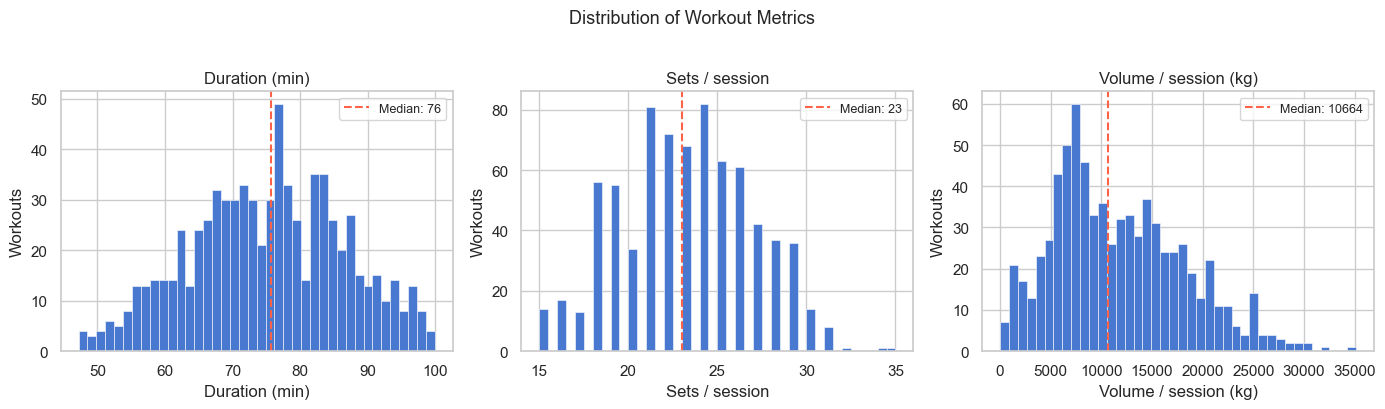

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

cols   = ["duration_min",   "total_sets",      "total_volume_kg"]
labels = ["Duration (min)", "Sets / session",  "Volume / session (kg)"]

for ax, col, label in zip(axes, cols, labels):
    ax.hist(workouts[col].dropna(), bins=40, edgecolor="white", linewidth=0.4)
    ax.axvline(workouts[col].median(), color="tomato", lw=1.5, linestyle="--",
               label=f"Median: {workouts[col].median():.0f}")
    ax.set(title=label, xlabel=label, ylabel="Workouts")
    ax.legend(fontsize=9)

plt.suptitle("Distribution of Workout Metrics", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

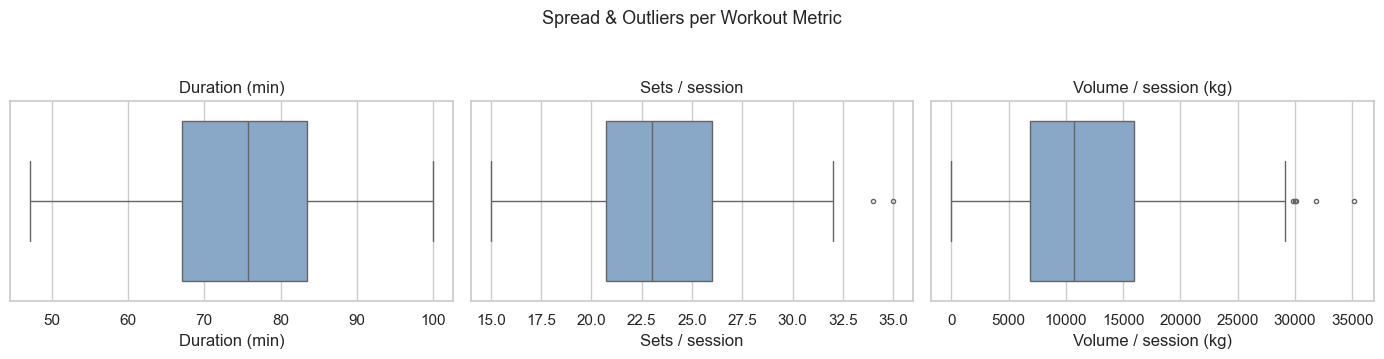

In [6]:
# Boxplots complement the histograms: they make spread and outliers explicit
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))

for ax, col, label in zip(axes, cols, labels):
    sns.boxplot(x=workouts[col].dropna(), ax=ax, color="#7fa8d1", fliersize=3)
    ax.set(title=label, xlabel=label)

plt.suptitle("Spread & Outliers per Workout Metric", y=1.05, fontsize=13)
plt.tight_layout()
plt.show()

## 3. Training Frequency Trend

Workouts per week over the full 6-year period, with a 12-week rolling average to smooth out holidays and gaps.

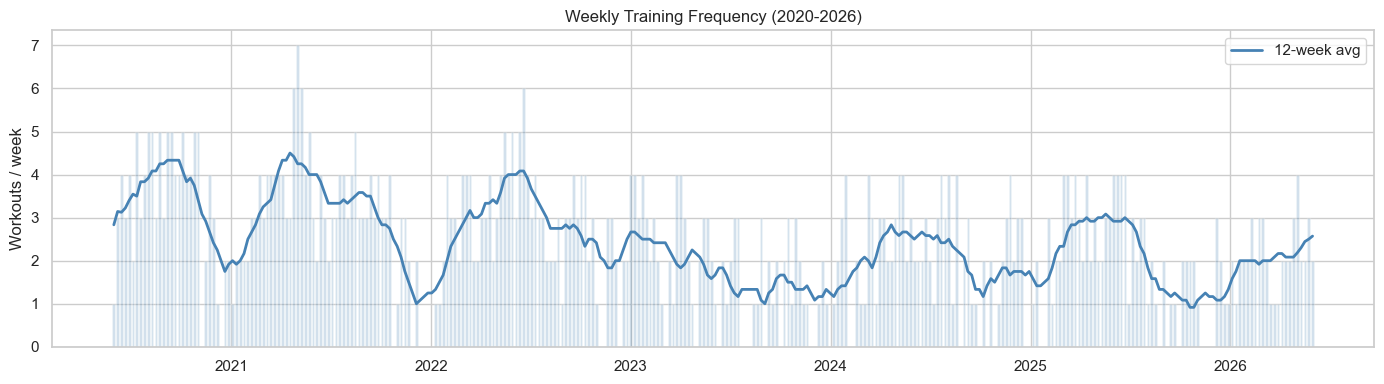

In [7]:
weekly = (
    workouts.set_index("date")
    .resample("W")["workout_id"]
    .count()
    .rename("workouts")
    .reset_index()
)
weekly["rolling_avg"] = weekly["workouts"].rolling(12, center=True, min_periods=6).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(weekly["date"], weekly["workouts"], width=5, alpha=0.25, color="steelblue")
ax.plot(weekly["date"], weekly["rolling_avg"], color="steelblue", lw=2, label="12-week avg")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.set(title="Weekly Training Frequency (2020-2026)", ylabel="Workouts / week", xlabel="")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Volume Trend

Monthly total volume (kg lifted) with a 3-month rolling average.

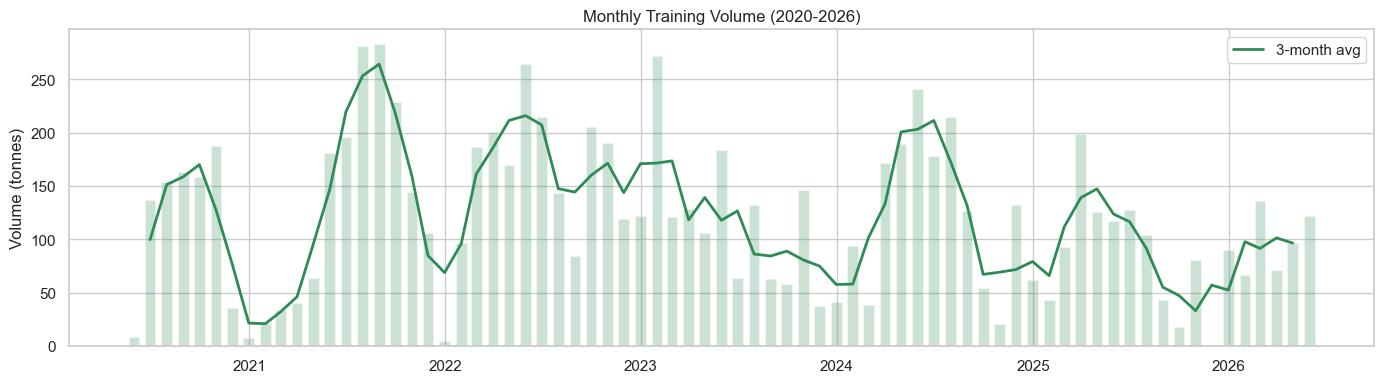

In [8]:
monthly_vol = (
    workouts.set_index("date")
    .resample("ME")["total_volume_kg"]
    .sum()
    .reset_index()
)
monthly_vol["rolling_avg"] = monthly_vol["total_volume_kg"].rolling(3, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(monthly_vol["date"], monthly_vol["total_volume_kg"] / 1000,
       width=20, alpha=0.25, color="seagreen")
ax.plot(monthly_vol["date"], monthly_vol["rolling_avg"] / 1000,
        color="seagreen", lw=2, label="3-month avg")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.set(title="Monthly Training Volume (2020-2026)", ylabel="Volume (tonnes)", xlabel="")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Strength Progression — Key Exercises

Monthly best estimated 1RM (Epley formula) per exercise, with a 3-month rolling average and a linear trend line.

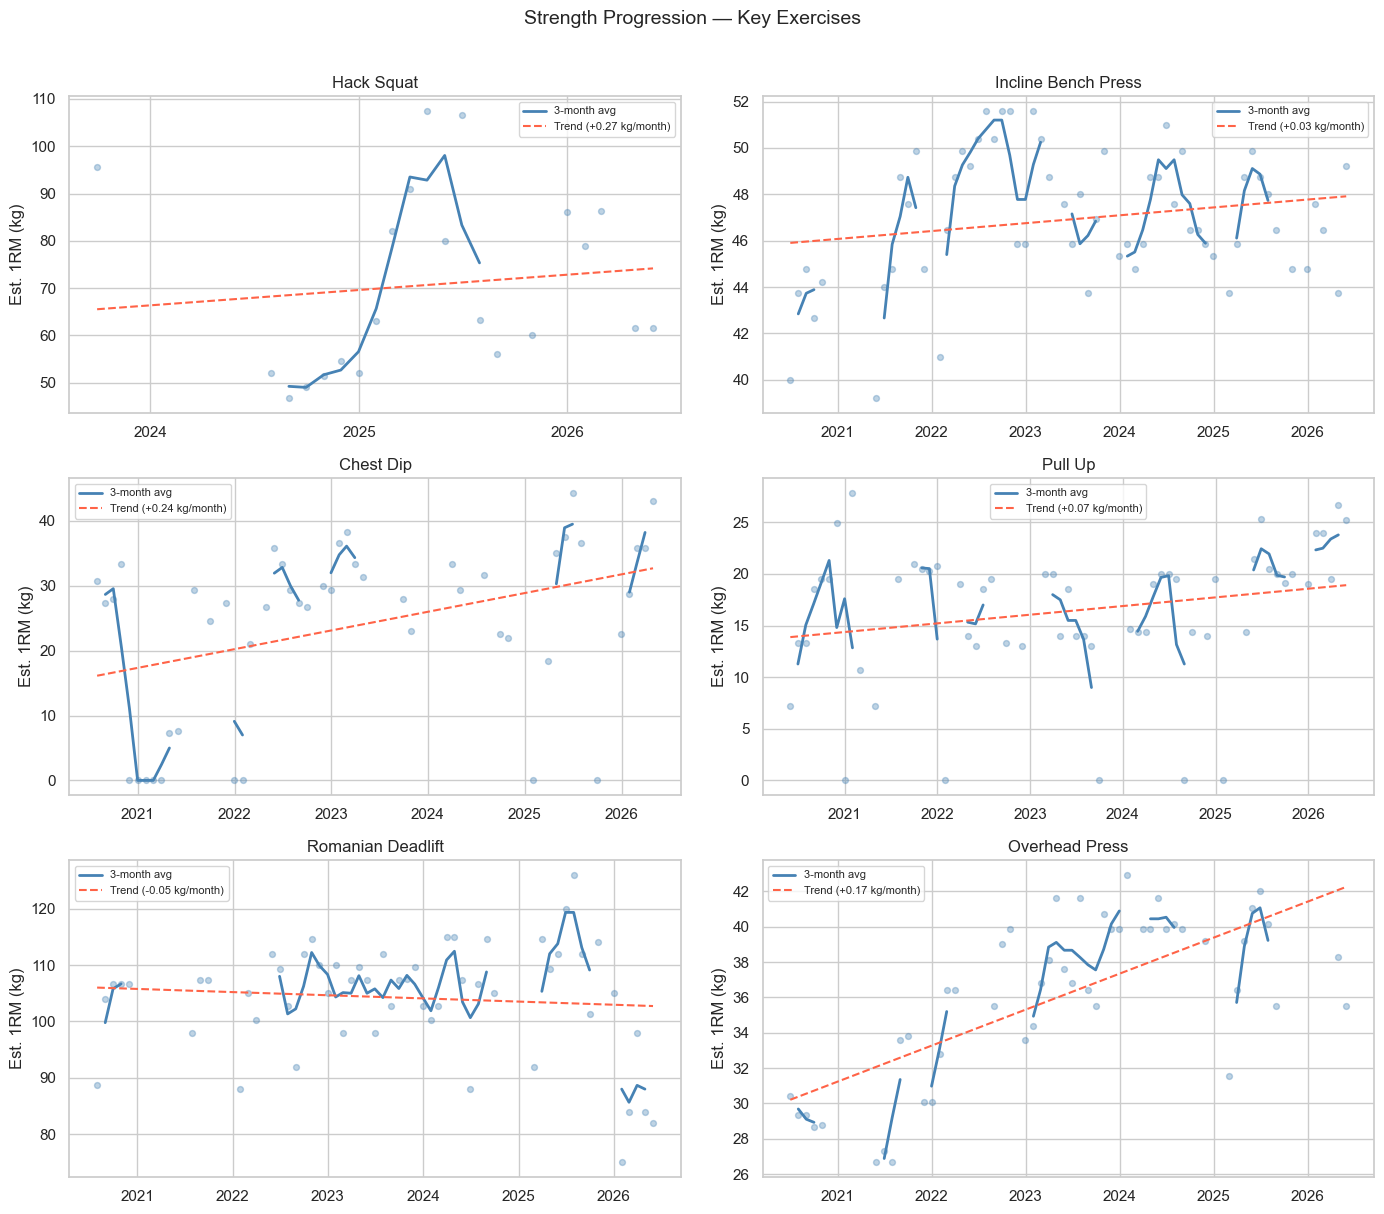

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (label, exercise) in enumerate(KEY_EXERCISES.items()):
    ex = sets[sets["exercise_name"] == exercise].copy()
    monthly = (
        ex.set_index("date")
        .resample("ME")["estimated_1rm"]
        .max()
        .reset_index()
    )
    monthly["rolling"] = monthly["estimated_1rm"].rolling(3, center=True).mean()

    # Linear trend line
    days = (monthly["date"] - monthly["date"].min()).dt.days.values
    valid = monthly["estimated_1rm"].notna()
    slope, intercept = np.polyfit(days[valid], monthly["estimated_1rm"][valid], 1)
    trend = slope * days + intercept

    ax = axes[idx]
    ax.scatter(monthly["date"], monthly["estimated_1rm"],
               alpha=0.35, s=18, color="steelblue", zorder=2)
    ax.plot(monthly["date"], monthly["rolling"],
            color="steelblue", lw=2, label="3-month avg")
    ax.plot(monthly["date"], trend,
            color="tomato", lw=1.5, linestyle="--",
            label=f"Trend ({slope * 30:+.2f} kg/month)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.set(title=label, ylabel="Est. 1RM (kg)", xlabel="")
    ax.legend(fontsize=8)

plt.suptitle("Strength Progression — Key Exercises", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. Correlation Analysis

Two levels of question:

1. **Which workout-level variables move together?** A Pearson correlation matrix over the numeric
   session metrics. Some relationships here are structural and expected (more sets means more
   volume) — the interesting part is which ones are *weaker* than intuition suggests.
2. **RQ3 — Does training more often in a month go together with a higher 1RM in that month?**
   Computed per key exercise and — unlike a bare correlation coefficient — reported with a
   **p-value**, so we can state whether the relationship is distinguishable from chance at all.

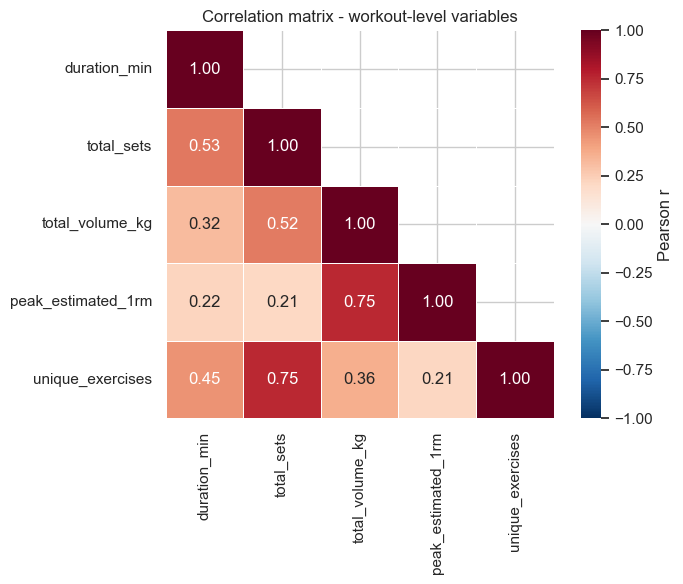

In [10]:
num_cols = ["duration_min", "total_sets", "total_volume_kg", "peak_estimated_1rm", "unique_exercises"]
corr_matrix = workouts[num_cols].corr(method="pearson")

fig, ax = plt.subplots(figsize=(7.5, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, linewidths=0.5, linecolor="white", square=True,
            cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set(title="Correlation matrix - workout-level variables")
plt.tight_layout()
plt.show()

In [11]:
monthly_freq = (
    workouts.set_index("date")
    .resample("ME")["workout_id"]
    .count()
    .rename("workouts_per_month")
)

results = []
for label, exercise in KEY_EXERCISES.items():
    monthly_1rm = (
        sets[sets["exercise_name"] == exercise]
        .set_index("date")
        .resample("ME")["estimated_1rm"]
        .max()
        .rename("best_1rm")
    )
    combined = pd.concat([monthly_freq, monthly_1rm], axis=1).dropna()

    # pearsonr also returns the two-sided p-value for H0: r = 0
    r, p = stats.pearsonr(combined["workouts_per_month"], combined["best_1rm"])
    results.append({
        "exercise": label,
        "n_months": len(combined),
        "pearson_r": round(r, 2),
        "p_value": round(p, 4),
        "significant (a=0.05)": "yes" if p < 0.05 else "no",
    })

corr_df = pd.DataFrame(results).sort_values("pearson_r", ascending=False).reset_index(drop=True)

# Format for display: the notebook-wide float format would round p-values to 1 decimal
corr_df.assign(
    pearson_r=corr_df["pearson_r"].map("{:.2f}".format),
    p_value=corr_df["p_value"].map("{:.4f}".format),
)


,exercise,n_months,pearson_r,p_value,significant (a=0.05)
0,Hack Squat,21,0.42,0.0556,no
1,Chest Dip,48,0.22,0.1303,no
2,Pull Up,57,0.20,0.1437,no
3,Romanian Deadlift,55,0.15,0.2837,no
4,Incline Bench Press,59,-0.00,0.9889,no
5,Overhead Press,48,-0.37,0.0090,yes


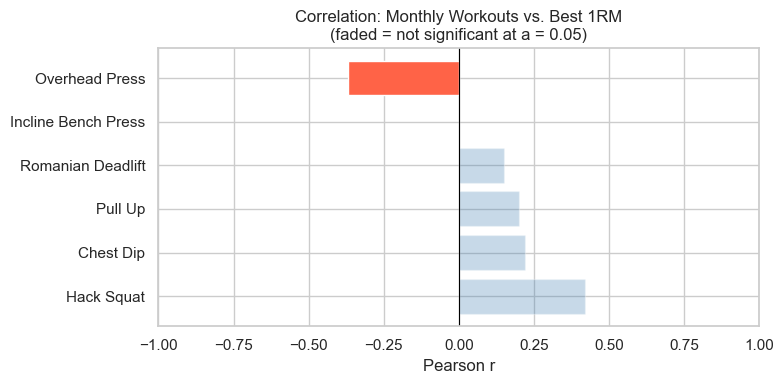

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["tomato" if r < 0 else "steelblue" for r in corr_df["pearson_r"]]
bars = ax.barh(corr_df["exercise"], corr_df["pearson_r"], color=colors)

# Fade out correlations that are not statistically significant
for bar, sig in zip(bars, corr_df["significant (a=0.05)"]):
    if sig == "no":
        bar.set_alpha(0.3)

ax.axvline(0, color="black", lw=0.8)
ax.set(title="Correlation: Monthly Workouts vs. Best 1RM\n(faded = not significant at a = 0.05)",
       xlabel="Pearson r", xlim=(-1, 1))
plt.tight_layout()
plt.show()

## 7. Linear Trend Model

The progression charts in §5 show the *shape*; this section quantifies it. For each key exercise an
**ordinary least squares regression** is fitted to the monthly best estimated 1RM over time, giving
three numbers a chart alone cannot: the **slope in kg per year**, **R²** (how much of the variation a
straight line explains) and the **p-value** (whether the slope differs from zero at all).

*This is a descriptive trend model, not a forecast.* Strength gain is not linear over six years — it
decelerates as a lifter approaches their ceiling — so the fit describes the average rate inside the
observed window and must not be extrapolated beyond it.

In [13]:
def fit_trend(exercise):
    # Monthly best 1RM regressed on time; returns None if the series is too short
    s = (
        sets[sets["exercise_name"] == exercise]
        .set_index("date")
        .resample("ME")["estimated_1rm"]
        .max()
        .dropna()
    )
    if len(s) < 6:
        return None
    years = (s.index - s.index[0]).days.to_numpy(dtype=float) / 365.25
    return s, years, stats.linregress(years, s.to_numpy(dtype=float))


fits, rows = {}, []
for label, exercise in KEY_EXERCISES.items():
    fit = fit_trend(exercise)
    if fit is None:
        print(f"Skipped {label}: fewer than 6 months of data")
        continue
    fits[label] = fit
    res = fit[2]
    rows.append({
        "exercise": label,
        "months": len(fit[0]),
        "slope (kg/year)": round(res.slope, 2),
        "R2": round(res.rvalue ** 2, 3),
        "p_value": round(res.pvalue, 5),
        "significant (a=0.05)": "yes" if res.pvalue < 0.05 else "no",
    })

trend_df = pd.DataFrame(rows).sort_values("slope (kg/year)", ascending=False).reset_index(drop=True)

# Format for display (see note above)
trend_df.assign(
    **{"slope (kg/year)": trend_df["slope (kg/year)"].map("{:+.2f}".format),
       "R2": trend_df["R2"].map("{:.3f}".format),
       "p_value": trend_df["p_value"].map("{:.5f}".format)}
)


,exercise,months,slope (kg/year),R2,p_value,significant (a=0.05)
0,Hack Squat,21,+3.24,0.012,0.63043,no
1,Chest Dip,48,+2.88,0.151,0.00632,yes
2,Overhead Press,48,+2.03,0.500,0.00000,yes
3,Pull Up,57,+0.84,0.053,0.08517,no
4,Incline Bench Press,59,+0.34,0.038,0.13858,no
5,Romanian Deadlift,55,-0.56,0.008,0.50427,no


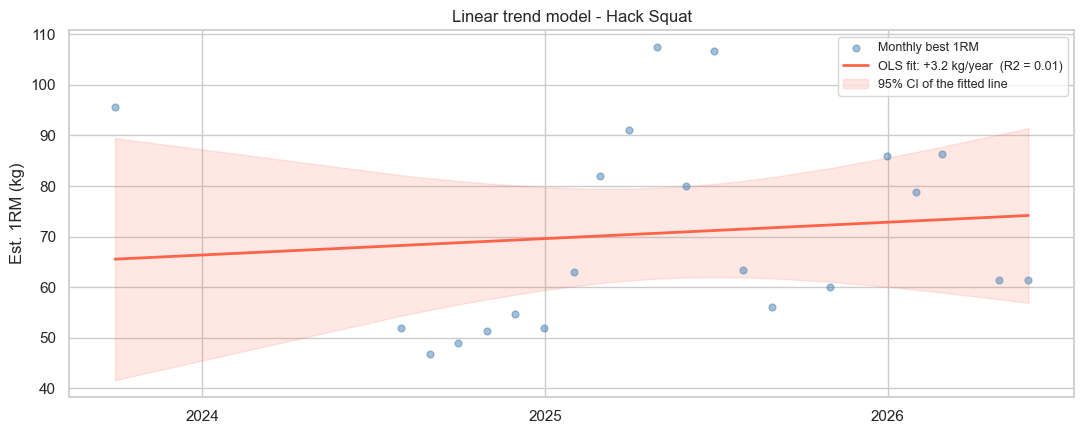

In [14]:
# Detailed view of the steepest trend, with a 95% confidence band for the fitted line
best_label = trend_df.iloc[0]["exercise"]
s, years, res = fits[best_label]

y_hat = res.intercept + res.slope * years
n, dof = len(years), len(years) - 2
resid_se = np.sqrt(np.sum((s.to_numpy(dtype=float) - y_hat) ** 2) / dof)
se_fit = resid_se * np.sqrt(1 / n + (years - years.mean()) ** 2 / np.sum((years - years.mean()) ** 2))
band = stats.t.ppf(0.975, dof) * se_fit

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.scatter(s.index, s.to_numpy(), s=24, alpha=0.5, color="steelblue",
           label="Monthly best 1RM", zorder=2)
ax.plot(s.index, y_hat, color="tomato", lw=2,
        label=f"OLS fit: {res.slope:+.1f} kg/year  (R2 = {res.rvalue ** 2:.2f})")
ax.fill_between(s.index, y_hat - band, y_hat + band, color="tomato", alpha=0.15,
                label="95% CI of the fitted line")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.set(title=f"Linear trend model - {best_label}", ylabel="Est. 1RM (kg)", xlabel="")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8. Personal Records Timeline

When was the all-time best estimated 1RM set for each key exercise?

In [15]:
pr_rows = []
for label, exercise in KEY_EXERCISES.items():
    ex = sets[sets["exercise_name"] == exercise]
    best_idx = ex["estimated_1rm"].idxmax()
    row = ex.loc[best_idx]
    pr_rows.append({
        "exercise":         label,
        "pr_date":          row["date"],
        "estimated_1rm_kg": round(row["estimated_1rm"], 1),
        "weight_kg":        row["weight_kg"],
        "reps":             int(row["reps"]),
    })

pr_df = pd.DataFrame(pr_rows).sort_values("pr_date").reset_index(drop=True)
pr_df

,exercise,pr_date,estimated_1rm_kg,weight_kg,reps
0,Pull Up,2021-01-14 15:01:51,27.9,22.0,8
1,Incline Bench Press,2022-07-10 14:08:42,51.6,36.0,13
2,Overhead Press,2024-01-28 16:43:19,42.9,28.0,16
3,Hack Squat,2025-04-11 17:32:41,107.5,75.0,13
4,Chest Dip,2025-06-12 13:42:50,44.3,35.0,8
5,Romanian Deadlift,2025-07-16 14:34:21,126.0,90.0,12


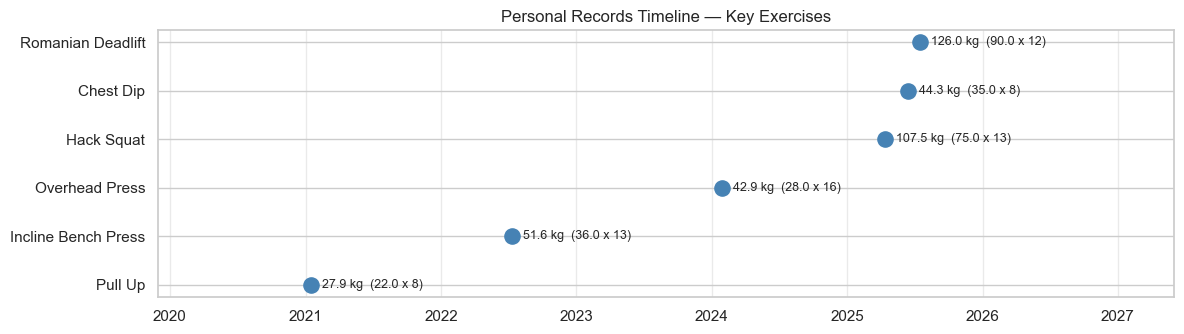

In [16]:
fig, ax = plt.subplots(figsize=(12, 3.5))

for i, (_, row) in enumerate(pr_df.iterrows()):
    ax.scatter(row["pr_date"], i, s=120, zorder=3, color="steelblue")
    ax.annotate(
        f"{row['estimated_1rm_kg']} kg  ({row['weight_kg']} x {row['reps']})",
        xy=(row["pr_date"], i),
        xytext=(8, 0), textcoords="offset points",
        fontsize=9, va="center",
    )

ax.set_yticks(range(len(pr_df)))
ax.set_yticklabels(pr_df["exercise"])
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.set(title="Personal Records Timeline — Key Exercises", xlabel="")
ax.set_xlim(pd.Timestamp("2019-12-01"), pd.Timestamp("2027-06-01"))
ax.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.show()

## 9. Weekday Training Heatmap

How is training distributed across the week, year by year?

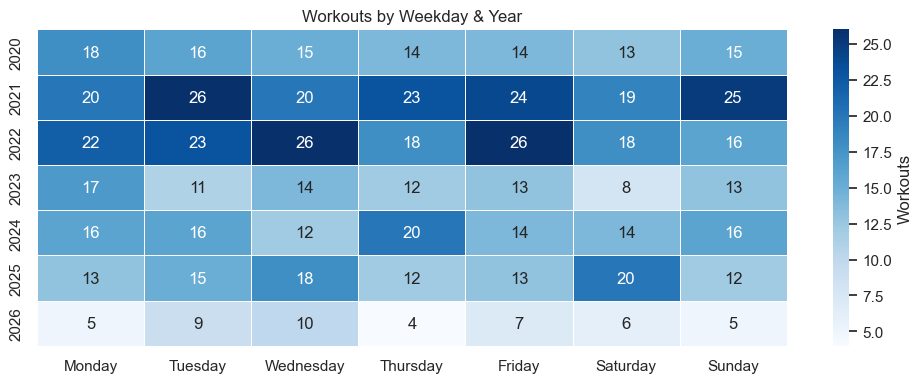

In [17]:
workouts["weekday"] = workouts["date"].dt.day_name()
workouts["year"]    = workouts["date"].dt.year

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

heatmap_data = (
    workouts.groupby(["year", "weekday"])["workout_id"]
    .count()
    .unstack(fill_value=0)
    .reindex(columns=weekday_order)
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    heatmap_data, annot=True, fmt="d", cmap="Blues",
    linewidths=0.5, linecolor="white", ax=ax,
    cbar_kws={"label": "Workouts"},
)
ax.set(title="Workouts by Weekday & Year", xlabel="", ylabel="")
plt.tight_layout()
plt.show()

## 10. Questions & Answers

The five research questions from `01_cleaning`, answered from the evidence above.

---

### RQ1 — How did total training volume develop over the six years?

**No sustained growth — and that is a finding, not a failure of the analysis.**
Annual volume rose from 852 t (2020, from May onwards) to a peak of **1,995 t in 2022**, then fell
back to 1,041 t in 2025. A linear fit on the monthly series gives −658 kg/month, but with
**R² = 0.04 and p = 0.10** that slope is not distinguishable from no trend at all. Volume is driven by
training phases and life circumstances, not by a steady six-year build.
*(2026 covers January–May only and is not comparable to the full years.)*

→ Evidence: §4, and the annual figures in §3.

---

### RQ2 — How did strength develop per key exercise, and how fast?

**Modest, slow, and uneven across lifts.** Of the six key exercises, only two show a statistically
significant upward trend:

| Exercise | Slope | R² | Significant |
|---|---|---|---|
| Chest Dip | **+2.9 kg/year** | 0.15 | yes |
| Overhead Press | **+2.0 kg/year** | 0.50 | yes |
| Hack Squat | +3.2 kg/year | 0.01 | no — only 21 months of data |
| Pull Up | +0.8 kg/year | 0.05 | no |
| Incline Bench Press | +0.3 kg/year | 0.04 | no |
| Romanian Deadlift | −0.6 kg/year | 0.01 | no |

The steepest raw slope (Hack Squat) is also the least trustworthy — a reminder that a slope without a
p-value is not a result. Importantly, the **personal-record timeline (§8) tells a more positive story
than the linear fits**: four of six all-time bests were set in 2024–2025, i.e. at the end of the
observation window. Progress is happening in steps, which a straight line captures poorly.

→ Evidence: §5, §7, §8.

---

### RQ3 — Does training more often in a month go together with a higher 1RM that month?

**No — and one exercise even points the other way.** Five of six exercises show no significant
relationship (p > 0.05; the closest, Hack Squat, reaches r = 0.42 at p = 0.056). The only
significant result is Overhead Press at **r = −0.37 (p = 0.009)**, i.e. *more* sessions went with a *lower* monthly best.

This is a case where the honest interpretation matters more than the number. It is not evidence that
training less makes you stronger. Two mechanisms explain it:

1. **The measurement window is wrong.** Strength adapts over weeks to months; a monthly correlation
   pairs cause and effect within the same bucket and therefore mostly measures noise.
2. **High-frequency months are volume blocks.** Periods with many sessions tend to be higher-rep,
   submaximal work, which mechanically lowers the *best* estimated 1RM of that month even while
   building the base for later peaks.

→ Evidence: §6.

---

### RQ4 — What temporal patterns exist?

**Steady frequency, no weekday habit.** Training averaged **2.41 sessions per week** (median 2).
Frequency peaked in 2021–2022 (157 and 149 sessions) and settled at roughly 90–110 per year after (88 in 2023, 108 in 2024, 103 in 2025).

The weekday distribution is strikingly **even**: every day carries between 13.0% and 15.3% of all
sessions, against a uniform expectation of 14.3%. There is no fixed "gym day" — sessions are
scheduled flexibly around the week rather than anchored to a routine.

→ Evidence: §3, §9.

---

### RQ5 — How does this compare to external reference points?

Answered outside this notebook, since it needs different data:
- **`04_comparison.ipynb`** — training frequency and progression shape against a second lifter's
  public dataset (721 Weight Training Workouts, Kaggle).
- **Streamlit dashboard, *Strength Standards* page** — the four best-documented lifts against
  strengthlevel.com community standards at 80 kg body weight.

## 11. Conclusion, Limitations & Recommendations

### Key findings

1. **Consistency, not growth, is the defining pattern.** Six years of training at ~2.4 sessions per
   week with no reliable trend in total volume. The dataset describes a maintenance-and-refinement
   phase, not a linear build-up.
2. **Strength still improved — where it was trained specifically.** Chest Dip (+2.9 kg/year) and
   Overhead Press (+2.0 kg/year) show significant gains, and most all-time records fall in the last
   two years of the window.
3. **Frequency alone does not explain strength.** At monthly resolution the relationship is absent or
   negative. Any claim that "training more often makes you stronger" is not supported by this data —
   which says more about the resolution of the measurement than about training theory.
4. **Session length is a poor proxy for session quality.** Duration correlates only weakly with volume
   (r = 0.32), while volume and peak 1RM correlate strongly (r = 0.75). Long sessions are not
   automatically productive ones.

### Limitations

- **n = 1.** This is one person's training history. Nothing here generalises to a population, and the
  Phase 6 comparison adds a second individual, not a sample.
- **Estimated 1RM is a formula, not a measurement.** The Epley estimate is well established but
  degrades at high rep counts; a 13-rep set converted to a 1RM carries real uncertainty.
- **Self-reported and self-timed.** Duration in particular is noisy — the reason for the quality
  filter in `01_cleaning`, whose sensitivity check shows the trends survive it (r = 0.988 between the
  filtered and unfiltered monthly volume series), though the exclusion of 11% of sessions remains a
  judgement call.
- **Drop sets excluded by design** (133 sets, ≈0.7% of volume) — documented in `01_cleaning` §3.
  Including them would raise total volume slightly without changing any trend.
- **Two sessions have zero volume** (bodyweight-only work) and legitimately pass the filter; they pull
  the volume mean down marginally.
- **The main confounders are simply absent from the data:** body weight, sleep, nutrition, stress,
  injuries and programme changes are not logged by the app, yet they drive strength progress. This is
  the single biggest constraint on every causal reading of these results.
- **Correlation is not causation**, and monthly aggregation is a coarse instrument for a process that
  adapts on a weekly-to-quarterly rhythm.

### Recommendations

**For training practice**
- Treat volume as a lever to be varied deliberately in blocks, not maximised — the data shows the
  highest-volume year (2022) is not the year of most personal records.
- The lifts with the clearest progression are the ones trained most consistently; sporadically trained
  lifts (Hack Squat: 21 months) cannot even be evaluated properly.

**For future analysis**
- **Log body weight.** It is the single most valuable missing variable: it would enable relative
  strength, proper benchmarking against standards, and body-weight-adjusted comparison with other
  lifters (the explicit gap in Phase 6).
- **Analyse at weekly resolution with a lag** (e.g. frequency in weeks *t−4…t−1* against 1RM in week
  *t*) instead of same-month correlation — the most likely reason RQ3 came back empty.
- **Fill in RPE.** It is present in the export schema but never used; it would separate "hard" from
  "long" sessions and give a real intensity measure.
- Segment the timeline into training blocks and compare block-level responses, rather than fitting one
  straight line across six heterogeneous years.

In [18]:
conn.close()
print("Done.")

Done.
